# Social_Network_Ads by SVM

## import libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

## Load dataset

In [5]:
data=pd.read_csv("Social_Network_Ads.csv")
data.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


## Understand dataset

In [6]:
data.shape

(400, 3)

In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


In [8]:
data.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


## Check missing values

In [9]:
data.isnull().sum()

Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

## Check target values

In [10]:
data["Purchased"].value_counts()

Purchased
0    257
1    143
Name: count, dtype: int64

## Select features and target

In [12]:
X=data[["Age","EstimatedSalary"]]
y=data["Purchased"]

In [14]:
X.head()

,Age,EstimatedSalary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000


In [15]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Purchased, dtype: int64

## Visualize the data 

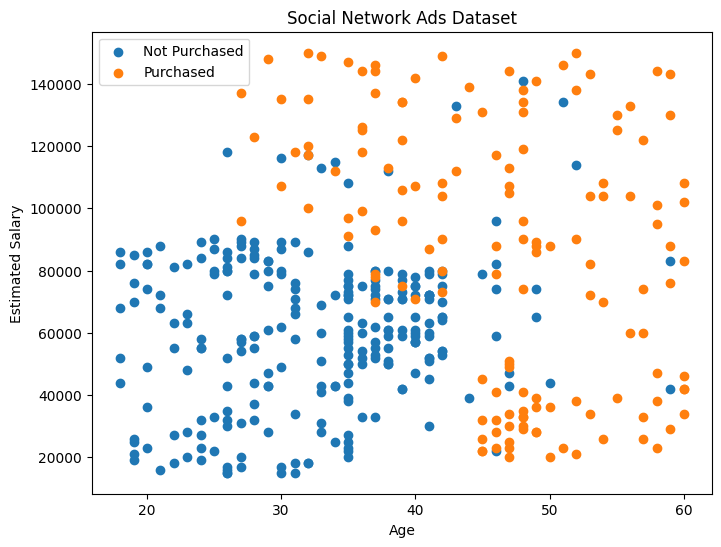

In [16]:
plt.figure(figsize=(8,6))
plt.scatter(
    data[data["Purchased"] == 0]["Age"],
    data[data["Purchased"] == 0]["EstimatedSalary"],
    label="Not Purchased"
)
plt.scatter(
    data[data["Purchased"] == 1]["Age"],
    data[data["Purchased"] == 1]["EstimatedSalary"],
    label="Purchased"
)
plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.title("Social Network Ads Dataset")
plt.legend()
plt.show()

## Train-test split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)
print("X_train :",X_train.shape)
print("X_test :",X_test.shape)
print("y_train :",y_train.shape)
print("y_test :",y_test.shape)

X_train : (320, 2)
X_test : (80, 2)
y_train : (320,)
y_test : (80,)


## Feature scalling

In [19]:
scaler =StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

## Create SVM model

In [21]:
model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale"
)

## Train model

In [23]:
model.fit(X_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


## Prediction

In [25]:
y_pred=model.predict(X_test)
y_pred

array([1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0])

## Accuracy

In [26]:
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy :",accuracy)
print("Accuracy (%) :",accuracy*100)

Accuracy : 0.925
Accuracy (%) : 92.5


## Confusion Matrix

In [28]:
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[47  5]
 [ 1 27]]


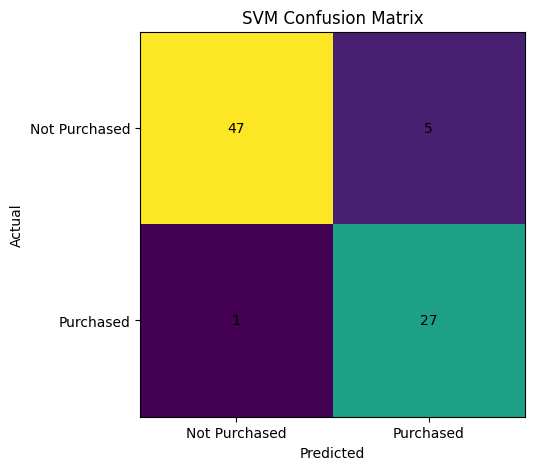

In [29]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["Not Purchased", "Purchased"])
plt.yticks([0, 1], ["Not Purchased", "Purchased"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

## Classification report

In [30]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.98      0.90      0.94        52
           1       0.84      0.96      0.90        28

    accuracy                           0.93        80
   macro avg       0.91      0.93      0.92        80
weighted avg       0.93      0.93      0.93        80



## Compare actual and predicted

In [31]:
result=pd.DataFrame({"Actual":y_test.values,"Predicted":y_pred})
result.head(20)

,Actual,Predicted
0,0,1
1,1,1
2,0,0
3,1,1
4,0,0
5,0,0
6,1,1
7,0,0
8,0,0
9,0,0


## Try Linear SVM

In [32]:
linear_svm = SVC(kernel="linear")

linear_svm.fit(X_train, y_train)

linear_pred = linear_svm.predict(X_test)

print(
    "Linear SVM Accuracy:",
    accuracy_score(y_test, linear_pred)
)

Linear SVM Accuracy: 0.8625


## Test different C values

In [33]:
C_values = [0.01, 0.1, 1, 10, 100]
for c in C_values:
    svm = SVC(kernel="rbf",C=c,gamma="scale")
    svm.fit(X_train, y_train)
    pred = svm.predict(X_test)
    acc = accuracy_score(y_test, pred)
    print("C =", c, "Accuracy =", acc)

C = 0.01 Accuracy = 0.65
C = 0.1 Accuracy = 0.925
C = 1 Accuracy = 0.925
C = 10 Accuracy = 0.925
C = 100 Accuracy = 0.9375


## Test different Gamma values

In [34]:
gamma_values = [0.01, 0.1, 1, 10, 100]
for g in gamma_values:
    svm = SVC(kernel="rbf",C=1,gamma=g)
    svm.fit(X_train, y_train)
    pred = svm.predict(X_test)
    acc = accuracy_score(y_test, pred)
    print("Gamma =", g, "Accuracy =", acc)

Gamma = 0.01 Accuracy = 0.85
Gamma = 0.1 Accuracy = 0.925
Gamma = 1 Accuracy = 0.9375
Gamma = 10 Accuracy = 0.9375
Gamma = 100 Accuracy = 0.775


## Predict a new customer

In [35]:
new_customer = [[35, 60000]]
new_customer_scaled = scaler.transform(new_customer)
prediction = model.predict(new_customer_scaled)
if prediction[0] == 1:
    print("Customer is likely to purchase.")
else:
    print("Customer is unlikely to purchase.")

Customer is unlikely to purchase.


C:\Users\rasto\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
